In [1]:
from langgraph.graph import START,StateGraph,END
from langchain_groq import ChatGroq
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel,Field
from langchain_core.messages import SystemMessage,HumanMessage
import asyncio

In [2]:
model=ChatGroq(model="llama-3.3-70b-versatile")

In [3]:
class ResumeState(TypedDict):
    original_resume_text:str
    original_job_description:str

    cleaned_resume_text:str
    cleaned_job_description:str

    match_score:int 
    similarity_score:int
    missing_skills:list[str]
    resume_skills:list[str]
    jd_req_skills:list[str]
    feedback:str
    iterations:int
    max_iterations:int

In [4]:
class ParsingSchema(BaseModel):
    cleaned_resume_text:str
    cleaned_job_description:str

structured_parsing_model=model.with_structured_output(ParsingSchema)

In [5]:
class ResumeSchema(BaseModel):
    resume_skills:list[str]
structured_resume_model=model.with_structured_output(ResumeSchema)

In [6]:
class JdSchema(BaseModel):
    jd_req_skills:list[str]=Field(description="list all the required skills mentioned in job description")
    
structured_jd_model=model.with_structured_output(JdSchema)

In [7]:
class SimilaritySchema(BaseModel):
    similarity_score:int =Field(ge=0,le=100,description="how well the resume matches description on a score of 100")
structured_similarity_model=model.with_structured_output(SimilaritySchema)

In [8]:
class aggregate(BaseModel):
    missing_skills:list[str]=Field(description="list all the missing skills from resume by comparing with jd req skills")
    match_score:int =Field(ge=0,le=100,description="how well the resume matches description on a score of 100")
structured_aggregate_model=model.with_structured_output(aggregate)

In [9]:
def parsing_phase(state: ResumeState):
    messages = [
        SystemMessage(content="""
You are a document cleaning specialist.

FOR RESUMES:
Remove headers, footers, contact details, links.
Preserve skills, experience, education, projects.

FOR JOB DESCRIPTIONS:
Remove company info, culture, fluff.
Preserve required skills, responsibilities, qualifications.

Return cleaned content EXACTLY mapped to schema fields.
"""),
        HumanMessage(content=f"""
RESUME:
{state['original_resume_text']}

JOB DESCRIPTION:
{state['original_job_description']}
""")
    ]

    response = structured_parsing_model.invoke(messages)

    return {
        "cleaned_resume_text": response.cleaned_resume_text,
        "cleaned_job_description": response.cleaned_job_description
    }


In [10]:
def extract_skills_resume(state:ResumeState):
    prompt=f"extract the skills in the resume : {state['cleaned_resume_text']}"
    response=structured_resume_model.invoke(prompt)
    return {"resume_skills":response.resume_skills}
def extract_req_skills_jd(state:ResumeState):
    prompt=f"extract the required skills from the job description: {state['cleaned_job_description']}"
    response=structured_jd_model.invoke(prompt)
    return {"jd_req_skills":response.jd_req_skills}
def similarity_score(state:ResumeState):
    prompt=f"""compare the resume :{state["cleaned_resume_text"]} and job descriptions required  {state["cleaned_job_description"]} and return a similarity_score how well the resume is contextually similar to job description"""
    response=structured_similarity_model.invoke(prompt)
    return {"similarity_score":response.similarity_score}
def aggregation(state:ResumeState):
    assert state["resume_skills"] is not None
    assert state["jd_req_skills"] is not None
    assert state["similarity_score"] is not None
    prompt=f"here's the resume skills of a candidate{state['resume_skills']} and jd required skills :{state['jd_req_skills']} and semantic similarity score :{state['similarity_score']} return missing skills and matching score"
    response=structured_aggregate_model.invoke(prompt)
    return {"missing_skills":response.missing_skills,"match_score":response.match_score}


In [11]:
def check_verdict(state:ResumeState ):
    if state["match_score"]>=70 or state["iterations"]>=state["max_iterations"]:
        return "apply"
    else:
        
        return "improve"

In [21]:
def needs_improvement(state:ResumeState):
    prompt=f"""You are a resume compliance editor, not a resume writer.

Your task is to apply controlled, minimal improvements to the resume provided below.

DEFINITION OF “IMPROVEMENT” (MANDATORY)

An improvement is ONLY one of the following actions:

Insert a skill from the “Missing Skills” list into an existing bullet point, or

Rephrase an existing sentence only to better reflect a skill that is already implied

❌ You MUST NOT:

Add new experience, roles, projects, or companies

Add new responsibilities or achievements

Add years of experience, seniority, or scope

Add certifications, tools, or skills not listed in “Missing Skills”

Claim hands-on experience that is not already implied

Create new bullet points

Expand or embellish any role

If a change does not meet the definition above, DO NOT make it.

SKILL-ANCHORED CHANGES (NON-NEGOTIABLE)

Every modification MUST:

Explicitly reference at least one skill from the “Missing Skills” list

Be directly traceable to the Job Description requirements

Modify only the bullet where the skill naturally fits

❌ Do NOT:

Rewrite bullets unrelated to Missing Skills

Improve wording for clarity, style, or impact unless a Missing Skill is being added

Add or infer skills not present in the Missing Skills list

If a bullet cannot safely incorporate a Missing Skill, leave it unchanged.

STRUCTURE PRESERVATION (STRICT)

You MUST:

Preserve all existing resume sections

Preserve job titles exactly

Preserve company names exactly

Preserve section order

Preserve bullet order

Preserve formatting and layout

❌ You MUST NOT:

Remove or rename sections

Merge bullets

Split bullets

Reorder bullets

Add new bullets

You may only edit text inside existing bullets.

EXECUTION RULES

Make the minimum number of edits required

If no valid improvement is possible, return the resume unchanged

Do NOT explain changes

Do NOT summarize

Do NOT add feedback or commentary

INPUTS

Current Resume:

{state['cleaned_resume_text']}


Job Description:

{state['cleaned_job_description']}


Missing Skills (authoritative list — use ONLY these):

{state['missing_skills']}

OUTPUT REQUIREMENT

Return ONLY the revised resume text.
No explanations. No analysis. No annotations."""
    response=model.invoke(prompt).content
    iterations=state["iterations"]+1
    return {"cleaned_resume_text":response,"iterations":iterations}
def good_fit(state:ResumeState):
    prompt=f"""Generate short feedback with:
                Strengths and
                Why resume matches role,here is the approved resume:{state["cleaned_resume_text"]} and job description:{state["cleaned_job_description"]}"""
    feedback=model.invoke(prompt).content
    return {"feedback":feedback}
    

In [13]:
graph=StateGraph(ResumeState)

graph.add_node("parsing_phase",parsing_phase)
graph.add_node("extract_skills_resume",extract_skills_resume)
graph.add_node("extract_req_skills_jd",extract_req_skills_jd)
graph.add_node("similarity_score",similarity_score)
graph.add_node("aggregation",aggregation)
graph.add_node("needs_improvement",needs_improvement)
graph.add_node("good_fit",good_fit)



graph.add_edge(START,"parsing_phase")
graph.add_edge("parsing_phase","extract_skills_resume")
graph.add_edge("parsing_phase","extract_req_skills_jd")
graph.add_edge("parsing_phase","similarity_score")



graph.add_edge("extract_skills_resume","aggregation")
graph.add_edge("extract_req_skills_jd","aggregation")
graph.add_edge("similarity_score","aggregation")

graph.add_conditional_edges("aggregation",check_verdict,{"apply":"good_fit","improve":"needs_improvement"})
graph.add_edge("good_fit",END)
graph.add_edge("needs_improvement","parsing_phase")
workflow=graph.compile()


In [14]:
initial_state={'original_resume_text':"""SUDHANVA H A 
7815060756,sudhanvaha1@gmail.com 
PROFESSIONAL SUMMARY 
Motivated and aspiring AIML student seeking a challenging role as a Machine Learning Developer or Data Scientist . 
Eager to leverage my technical skills, including proficiency in C, MySQL, and basic Python, along with a strong analytical 
mindset and passion for technology, to contribute to innovative projects and develop practical solutions as a valuable 
member of a dynamic team. 
EDUCATION 
Nitte Meenakshi Institute of Technology 
Bachelor of Engineering in Artificial Intelligence and Machine Learning      -CGPA 8.39/10 
ST Johns PU college 
Pre University Karnataka State board -588/600 (Percentage: 98) 
Karnataka  Cultural  Association  High  School                    
Bengaluru, Karnataka, India 
2021 - 2025 
Davanagere,Karnataka,India 
2019 - 2021 
Harapanahalli, Vijayanagar, Karnataka, India 
10th Grade Karnataka State board                                                                                                                                               -606/625 (Percentage: 96.96) 
TECHNICAL SKILLS 
2018  -  2019 
Languages: C, Python,Java,SQL 
Soft Skills: Effective Communication, Leadership, Teamwork, Problem Solving 
Libraries & Frameworks: NumPy, Pandas, Scikit-learn, Seaborn, Matplotlib, PyTorch, LangChain, FAISS 
EXPERIENCE 
Artificial Intelligence Intern. -Code Clause 
Sep. 2023 – Oct. 2023 
Remote 
• Developed and implemented a sales prediction model using linear regression, integrating it into a web interface for 
real-time predictions. 
• Addressed challenges like data preprocessing, feature selection, and model scalability, ensuring accuracy and 
reliability. 
• Suggested enhancements such as incorporating seasonality and advanced machine learning techniques for improved 
prediction accuracy 
PROJECT  
Credit Risk Modeling Using Machine Learning. 
• Preprocessed Data: Handled missing values and selected relevant features using Chi-square tests and VIF analysis. 
• Model Development: Built and optimized Random Forest, Decision Tree, and XGBoost models with hyperparameter tuning. 
• Model Evaluation: Evaluated models using precision, recall, and F1-score, and improved performance through feature 
engineering. 
YouTube Chatbot using LangChain and Hugging Face. 
• Built a Retrieval-Augmented Generation (RAG) pipeline to answer queries from YouTube video transcripts. 
• Used FAISS for semantic search with Hugging Face embeddings and LLM integration. 
Developed a modular LangChain workflow for transcript retrieval, question answering, and video summarization. 
CERTIFICATIONS 
Python coding with application projects and solutions 
Issued 2022 
Python 101 for Data Science 
Indoskill 
IBM 
Issued 2022""",
"original_job_description":"""Passionate in developing the next generation of deep-technological healthcare solutions to impact the lives of millions of expecting mothers and their families around the world. 
At least 6 months of hands-on experience in deep learning or machine learning research and development pertaining to image recognition: convolutional neural networks, optimization, hyperparameter tuning, model search, etc. 
Experience in: 
Language: Python.
Frameworks: PyTorch
Libraries: OpenCV, Pandas, PIL, Matplotib, etc. 
Analytical thinker with an innate inquisitiveness, relevant interests, and creativity. 
Basic understanding and knowledge in: 
Medical imaging processing. 
Real-time model development and deployment frameworks. 
Git and Git workflow. 
Ability to quickly read, understand and implement academic publications. 
Team player and eager-to-learn attitude. 
Ability to communicate complex ideas effectively - both verbally and writing - in English. 
Previous internship experience in early-stage startups is a plus. """,
"iterations":1,
"max_iterations":3
    
}
workflow.invoke(initial_state)

{'original_resume_text': 'SUDHANVA H A \n7815060756,sudhanvaha1@gmail.com \nPROFESSIONAL SUMMARY \nMotivated and aspiring AIML student seeking a challenging role as a Machine Learning Developer or Data Scientist . \nEager to leverage my technical skills, including proficiency in C, MySQL, and basic Python, along with a strong analytical \nmindset and passion for technology, to contribute to innovative projects and develop practical solutions as a valuable \nmember of a dynamic team. \nEDUCATION \nNitte Meenakshi Institute of Technology \nBachelor of Engineering in Artificial Intelligence and Machine Learning      -CGPA 8.39/10 \nST Johns PU college \nPre University Karnataka State board -588/600 (Percentage: 98) \nKarnataka  Cultural  Association  High  School                    \nBengaluru, Karnataka, India \n2021 - 2025 \nDavanagere,Karnataka,India \n2019 - 2021 \nHarapanahalli, Vijayanagar, Karnataka, India \n10th Grade Karnataka State board                                          

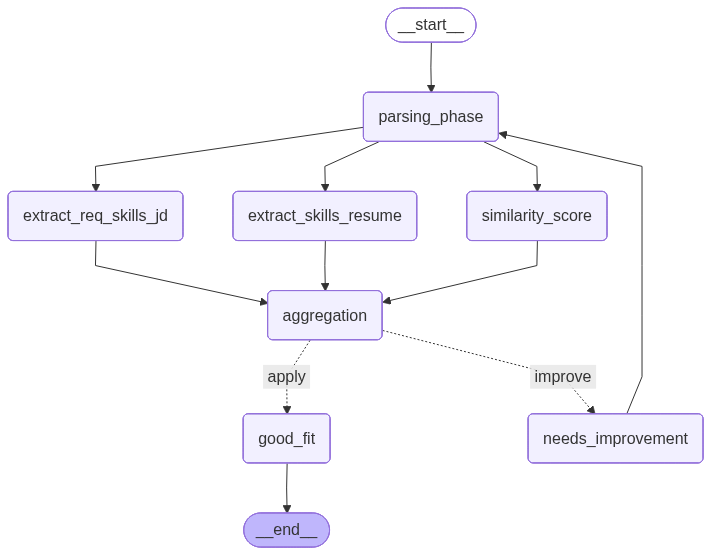

In [15]:
workflow